In [ ]:
import warnings
import random
import re
import json
import pickle
from collections import Counter
from itertools import combinations

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tqdm import tqdm

from gensim import corpora, models
from gensim.models import CoherenceModel, Word2Vec

import networkx as nx
import community as community_louvain

import os

warnings.filterwarnings('ignore')

RANDOM_STATE = 42
os.environ["CUBLAS_WORKSPACE_CONFIG"] = ":16:8"
np.random.seed(RANDOM_STATE)
random.seed(RANDOM_STATE)


data = pd.read_csv('/merged_output.csv')

# Preprocess

### 불필요한 단어 삭제

In [3]:
# 삭제할 단어
pre_word_deletion = {
"인공지능", "인공", "지능", "교육", "수업",
"㈜바로비젼",
"AI", "LG", "네이버", "웅진씽크빅", "구글", 
"스타트업", "엑사원", "메타", "회사", "오픈AI", 
"하이퍼클로바X", "LG유플러스", "키즈토피아", "갤럭시", "유튜브",
"GPT", "GPT-", "클로바", "링고시티", "KT", 
"바르코", "MS", "카카오", "VARCO", "ChatGPT", 
"엔씨소프트", "네이버클라우드", "마이크로소프트", "삼성전자", "경기도교육청",
"챗지피티", "엔씨", "아마존", "하이퍼클로바", "애플",
"웅진스마트올", "업스테이지", "코세라", 'CES', "엔비디아",
"엘리스그룹", "크레버스", "EBS", "뉴로클라우드", "미스트랄",
"챗엑사원", "과학기술정보통신부", "교원그룹", "KAIST", "다채움",
"플루닛", "한국앤컴퍼니그룹", "제미나이", "AIDT", "CNS",
"SKT", "SK", "딥브레인AI", "SK브로드밴드", "IBM", 
"삼성", "위버스마인드", "대전컨벤션센터", "서울대", "KMMLU",
"SK텔레콤", "코세", "뤼이드", "스픽", "도교육청", 
"솔트룩스", "소버린", "한국외대", "제플린", "매스프레소",
"북스토리", "애저", "유버스", "한화시스템", "Google", 
"카카오톡", "누리집", "실리콘밸리", "Chat", "AWS",
"유튜버", "서울사이버대", "딥시크", "콘진원", "카카오브레인",
"미디어젠", "TOPIK", "비상교육", "하이러닝", "MIT",
"AR피디아", "아티피셜소사이어티", "세이지", "TESOL", "GSB",
"유플러스", "카이스트", "EXAONE", "고려대", "스피", 
"디지털플랫폼정부", "엔지니어링", "무하유", "알리바바", "라마",
"딥브레인", "SKK", "성균관대", "버크셔", "스터디맥스",
"코파일럿", "Y교육박람회", "아이폰", "바이두", "연세대",
"커머스", "University", "Q.", "파이썬", "매쓰피드",
"메타슬랩", "중앙정부", "인텔", "LGU", "LG그룹",
"인스타그램", "리딩앤", "리딩", "DX사업본부장", "SKB",
"클레이디스", "플립6", "밴드", "씽크빅", "페이스북",
"조선", "퀴지움", "부산시교육청", "ZEM", "경기자동차과학고",
"틱톡", "헬피", "젠큐", "ChatEXAONE", "울산교육청",
"아이멘토", "삼성SDS", "미래교육", "페르소나", "파파고",
"아이포트폴리오", "데이원컴퍼니", "한국교육학술정보원", "ETF", "펀드",
"알파고", "바이트댄스", "인월드AI", "넷플릭스", "YTN",
"로라", "자스민그룹", "크롬", "Bard", "AI융합대학",
"베스핀글로벌", "인월드", "테슬라", "ixi", "GPT4", #2135
"지원청", "성남여중", "젬마", "GS", "OECD",
"피디아", "YBM", "ADVoost", "서울시교육청", "사이언스",
"미드저니", "이노베이션", "위키피디아", "위키", "USTA",
"펭톡", "경일대", "아마존웹서비스", "체그", "문화체육관광부", #2281
"멘쉬", "경일대", "USTA", "문화체육관광부", "과기", 
"TSMC", "딥마인드", "앤트로픽", "한동대학교", "기회발전특구",
"한국은행", "KMF", "네이버랩스", "디지털플랫폼정부위원회", "텔코LLM",
"전남도교육청", "S&P", "써밋", "인천대학교", "세타원",
"챗gpt", "사이버대", "유삐", "태재대학교", "오픈에이아이",
"NHN", "콴다", "디즈니", "스텝하우", "위캔버스",
"경기교육", "과기정통부", "VC", "Bing", "임팩트펀드",
"인디애나대", "클로드", "학나래", "4o", "아키핀",
"강서영어도서관", "DAN", "공주대학교", "프리윌린", "카나나",
"NHN에듀", "천재교과서", "한국마이크로소프트", "엘리스LXP", "백마고", #2652
"Bett", "칼리버스", "고양국제고", "SK하이닉스", "디피니션",
"자바", "엑셀", "행정안전부", "정통부", "CLOVA",
"SM엔터", "페르소나AI", "WSJ", "KDI", "메타버디",
"한국외국어대학교", "챕터코리안", "퍼플렉시티", "한양대", "중대",
"더불어민주당", "알파", "네이버플러스", "OpenAI", "영어마을",
"미라클레터", "멘슈", "서울사이버대학교", "충북교육청", "LG전자", 
"코스닥", "야당", "코웨이", "원더리드", "에누마",
"유선사업담당", "아시아투데이", "부산외대", "에듀템", "메디오",
"맥킨지", "고려대학교", "울산대", "듀오링고", "NAVER", #3044
"경희대", "유성아이", "지피티", "에듀플러스위크", "스탠퍼드",
"HyperCLOVA", "전라남도교육청", "울산대학교", "크로소프트", "KERIS",
"유데미", "유네스코", "딥엘", "GPT3", "원더풀플랫폼",
"SQL", "CMBO", "지구사랑탐사대", "수츠케버", "한국메타버스산업협회",
"한국콘텐츠진흥원", "스피킹맥스", "이화여대", "아스타", "파이낸셜뉴스",
"하버드대", "중소벤처기업부", "스탠퍼드대", "AMD", "트위터",
"NC", "EBN", "익시젠", "부산교육청", "앱스토어",
"구글번역", "아이플라이텍","제로엑스플로우", "텔레콤", "한국교육방송공사",
"디스커버리", "NHN클라우드", "세종사이버대", "chatGPT", "한국경제신문",
"HCX-DASH", "디케이테크인", "DX사업본부", "고양교육지원청", "순천향대학교",
"아이캔", "포항공대", "엔엑스", "이커머스", "캐피털", 
"메타빌드", "한국버스방송", "아이메디신", "로제타텍", "에이스에듀",
"홈피드", "아비카", "페르소", "STEAM", "AFP", 
"여수엑스포컨벤션센터", "울산시교육청", "아이스크림미디어", "AI스마트팜학과", "연세대학교", #3589
"교과교육연구회", "마스터케이", "텔코", "젬마2", "제주도민대학",
"NASA", "투블럭에이아이", "동원", "에드엑스", "숙명여자대학교",
"마이크로디", "클로바노트", "UN", "UVERSE", "코드모스",
"이솔초", "파운드리", "경복대학교", "교육혁신본부", "KNU", #3716
"제주도민대학", "NASA", "챗엑", "투블럭에이아이", "에드엑스",
"숙명여자대학교", "마이크로디", "클로바노트", "UN", "UVERSE",
"코드모스", "이솔초", "Science", "경복대학교", "KNU",
"포오", "세인트존스대", "한국과학기술원", "Gemma", "허깅페이스",
"AI부동산빅데이터학과", "AI크리에이터학과", "인천시교육청", "광주시교육청", "수학대왕",
"치프로", "KBS", "하버드", "버클리", "태재대",
"계약학과", "포티투마루", "국민대", "무신사", "인공지능산업융합사업단",
"남서울대학교", "SMCU", "존스홉킨스대", "국민일보", "시도교육청",
"로지벤처스", "프렌즈", "과학고", "HAE-RAE", "윈도우",
"뉴욕타임스", "마이프로필", "정보통신산업진흥원", "새벽배송", "뇌새김",
"아틀리에", "에듀코카", "미래교육박람회", "문부과학성", "깃허브", 
"가온플랫폼", "경기북과학고", "성남여자중학교", "송내고", "지방시대위원회",
"올림피아드", "서울대학교", "미스트리", "폴더블", "AI헬피",
"양천구청장상", "코드넛", "LG테크놀로지벤처스", "중앙일보", "퀘스천",
"투플랫폼", "월스트리트저널", "한화", "세타원코리아", "LG디스플레이",
"삼성닷컴", "AI컨택센터", "남서울대", "왓슨x", "인공지능학",
"IT동아", "서울특별시교육청", "팀네이버", "코GPT", "칠로엔",
"방송통신발전기금", "챗GPT4", "두바오", "스포츠서울", "R프로그램",
"퀄컴", "산업통상자원부", "피플", "국방경영학과", "유튜버들", "국민의힘",
"이투스", "카파샛", "에이럭스", "라쿠텐", "엔라이즈",
"송내고등학교", "슬램덩크", "에이닷", "비즈니스학", "소예키즈", #4632
"텐센트", "헬프나우", "한동대", "마이크론", "서경대학교",
"실용영어학과", "통일안보북한학과", "콘센트릭스", "현대자동차", "서울청사",
"전남교육", "링크드인", "팀스파르타", "벤처캐피털", "도이치텔레콤",
"라마3.1", "클로바X", "대전교육과학연구원", "켈리스쿨", "구글코리아",
"부산외국어대학교", "원티드랩", "뤼튼테크놀로지스", "이프랜드", "한림대학교",
"산의초등학교", "파이선", "엘리스클라우드", "고피자", "AI융합학부",
"광운대", "풀리캠퍼스", "스튜디오스&", "한국에듀테크산업협회", "스파크데스크", #4962
"그래니트", "홀딩스", "저스트랩스", "울릉고", "유진투자증권",
"부동산학과", "https://page.stibee.com/subscriptions/146096/NUrl",
"충북도교육청", "콜로소CIC", "스택오버플로우", "청담미디어", "소방산업",
"국가인공지능데이터센터", "GIST", "카맥스", "지메일", "엔브릭스",
"삼성스토어", "대전시교육청", "이데일리", "아이이에이", "인하대",
"HBM4", "따능AI", "디퓨전", "한국산업인력공단", "중기부",
"한국언론진흥재단", "서울경제신문", "나스닥", "미시간대", "세계시민교육",
"씨엔티테크", "대구시교육청", "효제초교", "루브르", "플렉스윈도우",
"강원대", "도요새잉글리시", "웅진북", "아이스크림에듀", "넷스케이프",
"신용보증기금", "투비유니콘", "코난테크놀로지", "조선신보", "웨비나",
"페이팔", "테크놀로지스", "디지털청", "서울관광재단", "화웨이",
"퓨리오사AI", "에이머스", "의정부여고", "비드콘", "영국문화원",
"솔라리노", "인네이처", "페어몬트", "비브스튜디오스", "기술교류회",
"부산교대", "제페토", "서치GPT", "다보스포럼", "와이컴비네이터",
"검정고무신", "테드", "풀릭스", "숭실대", "원구학교",
"랜드봇", "오픈이노베이션", "인터파크트리플", "터페이스", "AI서비스마케팅학과",
"아시아투데", "퓨리포터", "블룸버그", "씽크포비엘", "칼리지",
"컴업", "켄텍", "컴업", "카네기영어창의코딩학원", "한국응용언어학회",
"학하초등학교", "휴넷", "로톡", "가우디오랩", "이팝소프트",
"코히어", "서울캠퍼스", "조지아텍", "AI코스웨어", "브이몬스터",
"허드슨AI", "야나두", "디자인연구소", "알리", "네이처",
"베드록", "코카콜라", "에듀GPT", "윤선생", "핑크퐁",
"에듀테인먼트", "튜터러스랩스", "와이비엠", "매스GPT", "뉴시스",
"구글플레이", "타임지", "넥스트", "네카오", "노바테크",
"교육당국", "보건복지부", "매성고등학교", "대한경제신문", "클로즈드",
"한림대", "원더풀", "사회과", "자비스", "융합학",
"시드", "퍼스트", "로블록스", "영남취재본부", "경영대학원",
"매성중학교", "인터넷TV", "파닉스", "회원사", "캡스톤",
"영어교육지원단", "네이버앱", "게티이미지", "블루투스", "KT클라우드",
"카카", "현대카드", "고용노동부", "오픈AI사", "쿠팡",
"MetaX사업팀장", "에스디지유스", "노벨물리학상", "구글클라우드", "한국인공",
"정보통신기획평가원", "함평초", "심스리얼리티", "스탠포드",
"박람회장", "한양대학교", "컴퓨터공학과", "정보통신정책연구원", "더플라자호텔",
"여수세계박람회장", "마켓플레이스", "다비오", "챗네스트", "지니TV", #6436
"챗HK", "튼튼영어", "파주교육지원청", "버디", "국민경제",
"에이젯", "국방부", "매셋토", "경찰청", "현대백화점그룹",
"카네기", "보길초", "쭤예방", "에반", "아이언맨",
"싱글렉스", "국가디지털혁신지구", "칼텍스", "마음AI", "블라인드",
"디지털타임스", "중앙대", "부산대학교", "AI2X랩장", "루크안",
"서울테크밋업", "아이랩", "오디오테크", "다이렉트미디어랩", "AI허브",
"과학동아AiR", "옹진여름학교", "교보문고", "원장직무대행", "콘텐츠인재캠퍼스",
"동아사이언스", "매사추세츠공대", "메타버스프로젝트팀장", "버넥트", "통신부",
"교육지원청", "메일침프", "케이스텍스트", "이노시뮬레이션", "브레인AI",
"비브", "클레온", "알파블", "지니버스", "퀴즈렛",
"청담러닝", "행정학", "플레이스토어", "GPT킬러", "애스크업",
"파라다이스호텔", "사운드리퍼블리카", "텝스", "엔슬파트너스", "벡스코",
"세인트존스대학", "유튜브채널", "소프트뱅크", "국민대학교", "다큐프라임",
"사클레", "어드밴스드", "제주도교육청", "코챗GPT", "세계경제포럼",
"대전소방", "예일대", "공학과", "GPT스토어", "호텔업", 
"터프테크", "파블로항공", "한국전자통신연구원", "문화인류학", "국가직업분류대전",
"이코노미스트지", "과기부", "스마트베플리", "카카오프렌즈", "인공지능국민운동본부",
"남산중", "천재교육", "대한항공", "AI토피아", "대전교육청",
"위챗", "포자랩스", "한국AI교육협회", "코가로보틱스", "이루다",
"국가AI데이터센터", "마이리얼트립", "한국일보", "플루닛스튜디오", "왓츠앱",
"펜실베이니아주립대", "정보보호학과", "통계청", "대사관", "전국교직원노동조합",
"텔레그램", "투게더", "교육위원회", "LG계열사", "국립국어원", 
"에듀테크연구소장", "치매안심센터", "대전교육정책연구소", "해울",
"네이버배송", "부산대", "한국과학창의재단", "에픽게임즈", "AI서비스마케팅학",
"경기교육청", "전문대학원", "스탠포드대", "머니투데이", "기술정보방송통신위원회",
"융합교육정책과장", "강릉원주대", "스냅드래곤", "피아노과", "스택오버플",
"순천향대", "재팬", "앰틱스바이오", "신세계그룹", "상담심리학과",
"전기전자공학과", "프라이머사제파트너스", "앤스로픽", "국립평생교육진흥원", "SMART콘텐츠대학",
"메타콘텐츠융합전공", "위스퍼", "쿠다", "와디즈", "국정원",
"픽키즈", "대한무역투자진흥공사", "테라랩", "카카오테크", "뱅크오브아메리카",
"석사초등학교", "SM엔터테인먼트", "더핑크퐁컴퍼니", "사우스차이나모닝포스트", "컴퓨터게임디자인학과",
"아스타마이즈", "과학부", "데이원", "조지메이슨대", "라마2",
"쥬니버스쿨", "야후", "KB금융", "플레인베이글", "지방교육재정교부금",
"워터락", "큐챗", "에이블씨엔", "앤트그룹", "포항공과대학교",
"미스트랄AI", "에트리", "월드와이드웹", "충북고등학교", "통이치안웬",
"대한드론축구협회", "한국부동산원", "빌더랩", "플링크", "디플정위",
"넛지헬스케어", "카카오엔터테인먼트", "산업혁명위원회", "영덕사랑상품권", "푸르미르호텔",
"아트랩", "로봇융합학과", "경성대", "파머스국제어학원", "소우주컴퍼니",
"차란차", "부모나라", "브이디셔틀", "삼성화재글로벌캠퍼스", "삼성화재",
"프리드라이프", "이마트", "에듀트립", "화원고등학교", "경영대학",
"서부초등학교", "고산초등학교", "선린중학교", "숭문중학교", "운양고등학교",
"과학기술정보통신부장관상", "비엣", "현대차", "지스타", "한국영어평가학회",
"웨스틴조선서울", "퓨리오사", "경인교대", "광주교육", "선진엔지니어링",
"부동산학", "폴리인스퍼레이션", "현대백화점", "대덕넷", "전자공학부",
"지역학", "모션어드바이저", "영산대", "영문학", "한국수력원자력",
"태재미래", "제미나", "전문대학", "로이터", "수현초등학교", #8216
"버무즈", "삼성생명", "파이어폭스", "김일성대", "포터",
"비스포크", "오픈배지", "뉴욕페스티벌", "인천교육청", "유니버시티",
"에이블리", "길벗", "이스트소프트", "닛케이", "비트루브",
"DYB교육", "청와대", "기후테크", "웅진그룹", "에듀테크스쿨",
"클로드2", "그록", "더퀘스트", "로니에프앤", "아르키아",
"한국타이어", "세븐포인트원", "인천문화재단", "초코파이", "마이브라우니",
"커넥트웨이브", "액션파워", "엑스엘에이트", "레모네이드CIC", "세일즈포스",
"샵라이브", "하이퍼마인드", "카네기멜런대학교", "의정부여자고등학교", "위키미디어",
"디케이테크", "브리태니커", "스포티파이", "원더버스", "엘지그룹",
"미디어스피어", "한광여중", "알라딘", "동아일보", "정부세종청사",
"모델연기학과", "옥련여고", "한국디지털광고협회", "웨일", "한국지능정보사회진흥원",
"동국대", "한국거래소", "캐피탈", "방송통신위원회", "도쿄대",
"세종청사", "사회과학대학", "음악치료학", "군경상담학과", "기업은행",
"스타벅스", "블룸버그통신", "대교그룹", "빅스비", "라인웍스",
"보건행정학과", "금융보험학과", "가천대", "노인복지전공", "세무회계학과",
"건축공간디자인학과", "미래융합인재대학", "얍티비", "법무행정학과", "SW중심대학협의회",
"복지경영전공", "특수심리치료학", "육군사관학교", "오라클", "통합건강관리학과",
"영국교육기자재협회", "한경닷컴", "콴다봇", "한국교육평가원", "KBS미디어",
"케이타운포유", "웨이브아메리카스", "스튜디오드래곤", "한국수출입은행", "서울경찰청",
"영문과", "미래엔", "백악관", "한국전파진흥협회", "미시간대학교", 
"광주과학기술원", "경제협력개발기구", "대신증권", "글로벌무역물류학", "공예학과",
"건국대", "디자인대학", "게티이미지뱅크", "진흥원", "온라인커머스학과",
"매일경제", "노스웨스턴대", "산업부", "문화예술경영학과", "동의대",
"가족코칭상담학과", "앨리스", "국제통화기금", "혁신기초학부", "국방융합대학",
"한국투자증권", "경희대학교", "신한투자증권", "인공지능산학연연협회", "공룡월드",
"투마루", "오룡관", "픽사", "트라이버시티", "이프카카오",
"국립아시아문화전당", "스픽이지랩스", "폭스바겐그룹코리아", "수원교육지원청", "아티젠스페이스",
"늘봄", "한국MS", "성남교육지원청", "웨스틴조선호텔", "한국관광공사",
"포스코", "블랙웰", "대원", "이더리움", "페르소나에이아이",
"효성벤처스", "경기교육모아", "가트너", "큐원", "바이브",
"오룡중학교", "CJ올리브네트웍스", "한국연구재단", "쏘카", "서강대학교",
"중등영어교육비타민", "센스챗", "지브리", "중등교과교육연구회", "과학동아",
"따능스쿨", "롯데호텔", "튜더", "익스플로러", "첸원",
"씨젠", "비엘에프", "트레이더스", "국가인공지능위원회", "사피언스",
"충남초등영어교육연구회", "한국수자원공사", "이큐포올", "코스트코", "체더스",
"앙트러프러너십", "에이치디현대", "에이치디한국조선해양", "에이치디현대삼호", "오버플로우",
"한컴지니케이", "경향신문", "학성고등학교", "춘천교육대학교", "지오",
"울산광역시교육청", "에이치디", "한국앤컴퍼니", "조선대학교", "에버노트",
"퓨리서치센터", "NHN두레이", "S펜", "배민", "나사",
"학사초등학교", "아폴로", "성악과", "AI프렌즈", "잭슨랩",
"광주교육연구정보원", "녹스", "존디어", "벤앤제리스", "강원도민일보",
"알버타대학", "노회찬재단", "타이베이공업전문대학", "AI데이터융합학부", "코타나",
"주한영국문화원", "상록수협회", "한국항공대", "한국지역정보개발원", "홍천여자중학교",
"내일신문", "아이오테크", "하안도서관", "퍼플렉스티", "비두초등학교",
"뷰소닉", "원티드", "와튼", "데이터사이언스학부", "마이라이트",
"코바코", "사법연수원", "화원고", "애드부스트", "하나대체투자자산운용",
"삼성그룹", "파이브가이즈팀", "AI융합연구소", "한국유비쿼터스", "울산직업교육복합센터",
"지넷", "울산직업교육복합센터", "경남일보", "삼국유사군위도서관", "울산교육종단연구",
"수완중학교", "인하대학교", "마이AI", "저작권위원회", "인튜브",
"예술대", "마이메타", "남부노인복지관", "한국폴리텍대학", "한국조지메이슨",
"한국조지메이슨대", "목동미래교육센터", "경제학과", "해찬나래", "데이터과학과",
"브런치", "국립아시아", "경기북부청창사", "청년창업사관학교", "포뮬러",
"안산교육지원청", "동양미술학교", "옥스퍼드대학", "에디트", "지능정보산업협회",
"새김교육", "엘리스프로젝트", "플라이아시아", "부산관광공사", "코리아쿱오케스트라",
"시사포워드", "대구교육청", "한국공항공사", "왓슨스쿨", "위버스브레인", #10480
"웅진스마트올쿠키", # 2부터
"교육부", "바드", "엘리스", "유니콘", "전남교육청",
"산의초", "인천대", "그랜드볼룸", "사피엔스", "사관학교",
"선봬", "곡정고","북아이피스", "키즈랜드", "한영혼", "웨스틴",
"프로메테우스", "아이러닝", "콜로소", "웅진북클럽", "웅진북클럽",
"테무", "레서", "케어콜", "구몬", "충북교육",
"프리시던스", "스태티스타", "숙명여대", "한국어능력시험", "수트라",
"슬랙", "김포교육지원청", "루닛", "영어공공도서관", "유대교",
"이코노미스트", "웨이", "서큘러스", "엑스퍼트", "동아출판",
"매천고", "톈안먼", "아이패드", "메이트", "관광부",
"학산도서관", "상명대", "파르나스", "한울원전", "애니모비",
"포스트팁스", "웨이브", "도산서원", "대학수학능력시험", "문화일보",
"애플스토어", "알지오매스", "김일성종합대", "알렉사", "순천대",
"윌리엄스대학", "닥터나우", "안동대", "어썸맴버십", "부산외국어대",
"김일성종합대학교", "지능정보산업협회", "와이즈알파", "한국에너지공과대학교", "딜로이트",
"호주전략정책연구소", "한국문학번역원", "엔에이치엔", "한국광고총연합회", "세계시민교육원",
"하나벤처스", "옥스퍼드대학", "부산교육연구정보원", "경기자동차과학고등학교", "쌍봉초등학교",
"광주교대", "한국데이터산업진흥원", "한국장애인연맹", "크래프트테크놀로지스", "서울중앙지방검찰청",
"부산관광공사", "안산교육지원청", "플라이아시아", "엘리스프로젝트", "유니콘팩토리",
"한국기술교육대학교", "세계문화유산", "현대차그룹", "플레이스테이션", "위버스브레인",
"한국초기투자기관협회", "존스홉킨스대학", "당근알바", "국립서울현충원", "들미래교육센터",
"양천교육지원센터", "와이플래닛", "세계일보", "아카펠", "이솔초등학교",
"골드만삭스", "코리아쿱오케스트라", "아산나눔재단", "몽타미디어", "왓슨스쿨", 
"경기도민일보", "경기북부청창사", "청년창업사관학교", "비정상회담", "공주교육대학교부설초등학교",
"서경대", "제네시스랩", "프로보에듀", "브이디컴퍼니", "솔루니",
"에듀지피티", "라이트스피드시스템", "알레프에듀", "종로학원", "한국산업지능화협회",
"얀덱스", "매일신문", "웅진홀딩스", "동아대", "한국열린사이버대학교",
"주한영국대사", "웅진스마트올키즈", "한밭대학교", "한밭대학교", "대구가톨릭대학교",
"대구가톨릭대", "한일문화관광연구소", "서울과학기술대학교", "제이엘케이", "한광여고",
"중산고등학교", "한국문화인류학회", "인프랩", "에디트", "인텔코리아",
"구미도서관", "시어스랩", "두산인프라코어", "아이즈엔터테인먼트", "한국공항공사",
"서울세종고등학교", "숙명여고", "인사이더몽키", "옥스퍼드", "퍼시스그룹",
"상문고등학교", "단국대학교사범대학부속고등학교", "신일고", "대구교육청",
"갤럭시코퍼레이션", "자유대", "캔들로퍼", "웨스틴조선", "리인벤트",
"이비엔뉴스센터", "전주교대", "맥킨지앤컴퍼니", "하이닉스", "늘봄학교",
"파이낸셜타임스", "현대엔지니어링", "드림플러스", "영재학교", "머니투데이방송",
"우버", "퍼듀대", "알리바바클라우드", "큐캐피탈파트너스", "케이비",
"매경미디어그룹", "마소캠퍼스", "데이터닷에이아이", "지랩스", "용천초등학교",
"과학기술자문위원회", "국가교육위원회", "옥스퍼드대", "최승호", "한화생명",
"로앤컴퍼니", "지랩스코리아", "구글위협정보그룹", "뉴트론필드", "미디어크리에이터학",
"만화애니메이션학부", "게임콘텐츠학", "대성마이맥", "다락원", "일럿",
"교사노동조합연맹", "펜타곤", "네이키드니스", "사이버대학교", "융합경영대학",
"융합학과", "모집학과", "기계제어공학", "삼성에듀", "조총련",
"원격교육지원센터", "에누마코리아", "삼성케어플러스", "재일본조선인총연합회", "카카오헬스케어",
"로지브라더스", "서울교대", "범죄피해자지원센터", "수사본부", "디성센터", 
"소통과", "가족부", "경남도교육청", "리눅스", "가곡초등학교", 
"캘리포니아주립대", "교원라이프", "펭귄랜덤하우스" "평가원", "스노우플레이크",
"동국대학교", "메타버스서비스개발랩장", "패스트캠퍼스", "한국여성인권진흥원", "디성",
"경영학부", "벤처기업협회", "공정거래위원회", "서울시청", "카카오엔터프라이즈",
"모건스탠리", "비아이매트릭스", "파이낸셜", "균형발전박람회", "기획재정부",
"검찰", "롯데이노베이트", "위미니지먼트", "서울과학종합대학원", "혁신벤처단체협의회",
"벤츠", "폭스바겐", "한국디지털교육협회", "서울과기대", "잇피플",
"맥북", "중앙행정기관", "코리아스타트업포럼", "프라이머", "펀더멘털",
"경북도교육청", "숭실대학교", "한국청소년정책연구원", "더케이호텔", "애리조나주립대",
"토익스피킹", "중심대학협의회", "메가스터디", "에듀플러스", "비즈니스학과",
"배재대학교", "전남대학교", "빙챗", "지니아튜터", "공군사관학교",
"나치", "항공우주공학", "에어비앤비", "국방과학연구소", "상상인증권",
"매사추세츠공과대", "멀티미디어디자인학과", "간호사관학교", "서울시립대", "학군단",
"펜실베이니아대", "브이캣", "디지털정보위원회", "신경내과", "산타토익",
"인게이지먼트", "청암대", "드림아바타", "해군사관학교", "국제결제은행",
"기즈모도", "울릉고등학교", "대한상공회의소", "농업연구사", "조경회사",
"작물보호제회사", "종합법률정보시스템", "관리학", "엑싯", "공군",
"홍익대", "엔트로픽", "어도비", "스틱벤처스", "강릉원주대학교",
"마이써니", "카카오벤처스", "물가고용부", "화성오산교육지원청", "개인정보보호위원회",
"생명공학회사", "국립중앙도서관", "방배노인종합복지관", "노인복지관", "서울경제진흥원",
"동주민센터", "현대자동차그룹", "에듀랩", "한국정보통신기술협회", "동대문디자인플라자",
"인천광역시교육청", "한국소프트웨어산업협회", "법원도서관", "한국교원단체총연합회", "세종대",
"한국어문화학", "충남교육청", "세븐일레븐", "셀바스", "사업청",
"한국교원대학교", "작물육종회사", "한신대학교", "포스텍", "청암대학교", 
"상명대학교", "울산기초학력지원센터", "언론중재위원회", "울산공고", "두드림학교",
"울산기후위기대응교육센터", "국민권익위원회", "서울창조경제혁신센터", "단국대", "여우락",
"국립아시아문화전당재단", "국립오페라단", "오페라단", "럭스마키나", "광운대학교",
"한국정책학회", "스포츠과학", "코리아쿱", "플라자", "서남센터",
"직업교육복합센터", "에이블씨엔씨", "해양전문대학", "대만대학", "울산교육종단",
"울산교육연구정보원", "루디나인", "정부재정지원사업", "토토영어", "패밀리앱상",
"차이콥스키홀", "일리노이대", "엑스프라이즈", "상도중", "팀모노리스",
"필리핀한인총연합회", "국가통계포털", "창조경제혁신센터", "한국방송광고진흥공사", "리틀송뮤직",
"알엠피", "플루럴사이트", "필리핀한글학교", "한글학교", "에트리홀딩스",
"충청북도교육청", "충북교육청제공", "존슨홀", "스버드럽사", "컴퓨터과학과",
"동춘천초교", "춘천교대", "춘천교육지원청", "외대", "프린스턴",
"아이비엠", "국방무기체계연구", "흑백요리사", "한국실천공학교육학회", "보스턴다이내믹스",
"정치외교학과", "글로컬미래교육박람회", "공예디자인학과", "부동산자산경영학과", "시도교육감협의회",
"경찰학과", "기계공학과", "세종사이버대학교", "금융학과", "국방융합학과", 
"환경조경학과", "아동학과", "소방방재학", "한양경제", "사회복지행정학과",
"타이베이대학", "호텔관광경영학과", "소프트웨어공학과", "유튜버학과", "도시계획학과",
"한국어학과", "에이스에듀만", "경북대학교", "소믈리에학", "서비스경영학과",
"사회복지학과", "실용음악학과", "예술치료학", "외식창업프랜차이즈학", "부동산경매중개학과",
"만화애니메이션학과", "유통물류학과", "산업안전공학과", "온라인마케팅학", "소방행정학과",
"한울원자력본부", "네이버표", "콘진", "평촌초", "평촌초등학교",
"패들렛", "한국과학기술연구원", "충북일보", "센트럴홀게이밍", "웅진진씽크빅",
"오사카세계박람회", "한국경제", "동아경제",
"인공ㄹ지능", "맹모삼천지교",
"딥아이", "삼성중공업", "한화오션", "울산콤플렉스", "유니이티드어소시에이츠",
"에스덕", "루카스에듀테인먼트", "디케이메디인포", "토도수학", "부산정보산업진흥원",
"미네르바에듀", "성결대", "삼례중", "훙즈중학교", "한국강사신문",
"남산중학교", "맥킨지컨설팅그룹", "플레이앱스토어", "어플라이드머티어리얼즈", "지드라이브",
"서울신문", "재미나이", #11217
"네이버", "구글", "웅진씽크빅", "코엑스", "스튜디오스", #3
"시교육청", "클라썸", "프로키즈북", "인공지능학과",
"읽걷쓰",
"성균관대학교", "베드락", "엘리프", "양천공원", "수퍼톤",
"엑스", "퍼스트펭귄", "골드앤에스", "다산홀", "드랩",
"웨비", "하회마을", "사회복지전공", "사회복지대학", "토론토대",
"디살리노", "한동대학", "엘리스라이브러리", "남부종합사회복지관", "한국소비자연맹",
"푸단대", "중국정부", "딥시크포위망", "교원단체", "전자랜드",
"해법독서논술", "이에이트", "주립대", "경영대", "가천대학교",
"컬리", "챕터서울", "지방자치박람회", "오토드로우", "스카이라이프",
"교육대", "대한경제", "국민당", "더픽트", "메텍",
"국제경영대학발전협의회", "회계학", "유망학과", "컴퓨터게임디자인", "컴퓨터게임디자인학",
"안보정책연구소", "엔데버", "서호임팩트", "원라인에이아이", "중앙교육심의회",
"바틀리스트", "미래에셋증권", "이솔초등", "청창사", "작업부회",
"조지메이슨", "트왈렛", "이솔초등학교오늘", "경기미래학교", "삼성증권",
"인천글로벌캠퍼스", "미래교육원", "혁신대학", "미래교육원", "대전기업",
"한국정보방송통신대연합", "링코시티", "중옌푸화", "구글닷오알지", "국제전자제품박람회",
"홍커우", "케세라게임즈", "토토수학", "덴티큐브", "중소벤처기업진흥공단",
"공공도서관", "대구북부도서관", "대구서부도서관", "대구수성도서관", "깁슨",
"과천과학관", "편집자주아시아경제", "제미니", "드론로봇융합학", "비티비",
"린북", "읽걷",
"전국시도교육감협의회", "충청대", "도민로스쿨", "매일경제신문사", "태재미래전략연구원",
"아이비리그", "매스지피티", "제주평생교육장학진흥원", "메다버디", "공군창업경진대회",
"인재영입위원회", "고래가숨",
"새얼문화재단", "영어교육격차해소지원단", "국립세계문자박물관", "농협", "출판기념회",
"음악교육과", "기계자동차공학부", "모빌리티공학과", "에선", "기후변화센터",
"국립공주대학교", "트웨스턴플러스호텔", "돌마고등학교", "고양국제고등학교", "수원외국어고등학교",
"제주특별자치도교육청", "데이터정보물리학과", "교육학과", "충북대학교", "일송자유교양대학",
"식물자원학과", "니메이션", "음대", "사립유치원", "퀴엄",
"테솔", "지학사", "대전교육가족", "인터컨티넨탈호텔", "한스미디어",
"조지아대", "여호와", "아이러브북", "알파폴드", "엔슬파트너스등",
"팁스타운", "낫네",
"산학연협력", "노블코믹스", "투썸플레이스", "마이니치", "이러닝연구소",
"비영리재단", "제로원", "수학동", "어린이과학동아", "어린이수학동아",
"영재교육원", "과학고등학교", "클라비", "한국정보화진흥원", "소트프제국",
"신정초", "삼체", "머니투데", "서울대학교발전재단", "인문정보연구소",
"이호영", "이준환", "의회협의회", "유나이티드헬스그룹", "맥도날드",
"어드밴스트마이크로디바이시스", "필라델피아반도체지수", "광주교육청", "서울교육청", "건강보험심사평가원",
"현대오토에버", "파라다이스시티", "동의대메타버스교육연구소", "더중플", "더중앙플러스",
"읍면사무소", "교육과학기술부", "토도영어", "엔젤", "국도화학",
"패브릭스", "인천국제공항공사", "대구센터", "충남북부상공회의소", "현대이지웰", 
"한국콜마", "한국타이어앤테크놀로지", "배틀필트", "에이치디현대미포", "현대중공업",
"시이에스", "체어맨", "야리까리", "퇴근해", "시마이쳐", #?
"오사마리", "앵그리버드", "하나금융지주", "세종대학교", "홍콩과기대",
"딥노이드", "홍콩과기대", "회계법인", "지오플랫폼", "충남대학교",
"단국대학교", "서울시중부교육지원청", "위키드스톰", "오르드", "스쿨에이아이",
"동아대학교", "제공한국앤컴퍼니그룹", "엘리스랩", "토이스토리",
"스마트올", "플립", "엑스포", "코리아", "폴드", 
"링글",
"그다음",
"디스플레이", "콜로퀴엄", "아짓", "국어과", "태재",
"의대", "이사회", "경제학", "굿노트", "이슬람",
"공학부", "민주당", "년간", "시리", "물리학",
"토익", "국민은행", "헬로루디", "수학과", "법무부",
"한국사", "이틀간", "이젠", "문체부", "조사국",
"지방자치단체", "사이버대학", "당근", "첨단산업단지", "켈리",
"패스트", "헤이젠", "혁신지구", "허깅", "페이스",
"디쉐어", "기계공학", "특허청", "컴퓨터공학", "공대",
"경영학과", "한겨레", "외국어교육센터", "공산당", "이슬람교",
"로보틱스", "기독교", "튀르키예", "인프런", "도덕과", 
"공과대학", "정보학", "케이쓰리아이", "쥬니버", "코챗", 
"엘지", "글들", "난디니", "함무라비", "비짓서울", 
"어퓨", "아세안", "양천구청", "동물학", "전산학",
"조직위원회", "웹문예창작학", "음악대학", "파이드로스", "토의세미",
"세이지메이커", "키닛", "글로컬대학", "주간경향", "학교운영위원회",
"와튼스쿨", "대입톡", "오모테나시", "메타버스학", "코퍼레이션",
"서울교육", "소니", "회사명", "약학", "하이브",
"뉴튠", "쓱렌즈", "나군", "비짓부산", "보호학",
"살레시", "사법부", "공주대", "스킬스빌드", "스파이글라스",
"금성출판사", "숙명여자고등학교", "워싱턴포스트", "음성학", "승학초",
"동수영중", "국제학과", "외국인주민지원센터", "충북교육연구", "전교조",
"계향쓰", "으뜸학교", "으뜸", "민달리", "그랑제꼴",
"커다쉰페", "티머니", "대전소방본부", "랩투아이", "치마이",
"플릿튠", "스마일게이트", "미라지", "삼호고", "천부초",
"천태초", "인민일보", "배재대", "광주창의융합교육원", "광주교육연수원",
"청암초", "신동중", "성덕중", "슈밥", "째주",
"금융감독원", "폭스바겐그룹", "볼프스부르크", "동의하", "자비에",
"자동차공학과", "눈높이스쿨원", "기획예산과", "속초시청", "한국환경공단",
"근로복지공단", "하나카드", "국립과학수사연구원", "게스", "디지털정당위원회",
"공공부처", "국가정보원", "엘리스스쿨", "한국오라클", "맥킨지서베이",
"독일노동경제연구소", "신슈대학교", "섬유학부", "포브스지", "몬스터",
"스켈터랩스", "스캘터랩스", "한국열린사이버대", "인공지능융합학", "강의창",
"열린사이버대", "명최근", "야파급력", "픽사베이",
"영어", "미국", "한국어", "일본", "중국",
"베트남", "한글", "유럽", "아시아", "영문", 
"프랑스", "대전", "싱가포르", "말레이시아", "이스라엘",
"필리핀", "캐나다", "동남아사이", "강남구", "유성구", 
"양천구", "태국어", "도쿄", "서울시", "호주",
"팔레스타인", "베트남어", "중국인", "중구", "오산시",
"인도네시아", "수도권", "인천", "지구", "남미",
"울릉군", "서초구", "교육발전특구", "경기도", "런던",
"브라질", "부산시", "프랑스어", "독일어", "파리",
"스위스", "오세아니아", "북한", "제주도", "올비아",
"파주", "폴란드", "독도", "강남", "뉴질랜드",
"경북", "사우디아라비아", "홍콩", "아프리카", "시드니",
"러시아어", "모국어", "강원", "베이징", "여의도",
"인도네시아어", "광주광역시", "브루나이", "광화문", "아랍어",
"제주", "케냐", "오산", "세종시", "캘리포니아",
"가자지구", "포르투갈어", "보스턴", "가우스", "스웨덴",
"중국판", "워싱턴", "소공동", "캘리포니아주", "미얀마",
"충북", "아르헨티나", "핀란드", "알버타", "인천시",
"전라남도", "화성특례시", "캄보디아", "이태원", "경기북",
"성남시", "삼성동", "우크라이나", "대치동", "해운대",
"옹진군", "미국인", "리앙", "헝가리어", "이탈리아",
"이집트", "시애틀", "타이완", "경상북도", "구미시",
"아랍에미리트", "타이베이", "은평구", "타이난", "대만인",
"항저우", "한자어", "한강", "동래구", "상하이",
"사우디", "울산시", "광주시", "파라나주", "성남",
"알버타주", "김포", "네팔", "로스앤젤레스", "로마", 
"종로구", "교육도시", "광명시", "홍릉", "영토분쟁지역",
"네덜란드", "관악구", "송파구", "창원", "몽골어",
"유대인", "이탈리아어", "카라그푸르", "후쿠시마", "미중",
"진주", "전라도", "옥스포드", "아랍", "싱가폴",
"뉴욕시", "알아크사", "수원시", "라오스", "잉글리시",
"워싱턴주", "일본인", "덴마크", "부천", "구미",
"화성시", "해운대구", "동탄", "충남", "서안지구",
"아일랜드", "구로구", "특례시", "안산", "대표도시",
"북캘리포니아", "오산시민", "원자력연", "용인", "위구르족",
"강원도", "남구", "충청", "과천시", "프레즈노",
"서울광장", "캄보디아어", "도쿄서", "도심융합특구", "동북아",
"용인시", "청나라", "명나라", "힌두어", "폴란드어",
"라틴아메리카", "동남아인들", "선산군", "요하네스", "우면동",
"루마니아", "분당구", "맨해튼", "파키스탄", "자치구",
"오슬로", "안양", "경복궁", "헝가리", "영덕군",
"경북도", "울릉도", "요르단", "성북구", "성동구",
"강원특별자치", "히로시마", "오스트리아", "광안대교", "주한미국",
"힌디어", "구자라트어", "타밀어", "루이지애나", "선진도시",
"앨라배마", "미시시피주", "서초동", "충주", "아시아인",
"제주특별자치도", "울진", "네바다주", "서부산", "산직동",
"바라나시", "위구르자치구", "중화민국", "우주베키스탄", "한일",
"휴스턴", "텍사스주", "위구르인", "웨스턴", "일리노이",
"옹진부", "부산시민", "역삼동", "로스알토스힐스", "뉴델리",
"무주", "국민연합", "동래읍성광장", "펜실바니아", "타밀",
"마두라이", "첸나이", "사미르", "클루지나포카", "강릉",
"인디애나", "유태평양", "평창", "춘천시",
"슈만", "아벨", "요시", "아틀리", "김명현",
"말콤", "정보원장", "콜하트카르", "김정태", "김현철",
"본부장들", "힌턴", "한세진", "이서현", "노엄",
"이상민", "이성수", "미첼", "최재경", "사외이사",
"하병훈", "교육혁신원장", "유영준", "오마르", "이기환", 
"이씨", "정의선", "김대리", "윌슨", "박은주",
"강하루", "카나", "행크스", "시현", "오용수",
"이사장님", "모네", "기술총괄", "코난", "회장님",
"벳순", "최상목", "최고기술경영자", "박태웅", "겸임교수",
"무스타파", "매튜", "김종한", "성과리더", "부장교사",
"마화텅", "아이즈", "릴월씨", "대학교수", "노원준",
"선임연구원", "허영주", "명예교수", "정상구", "수석부사장",
"호크마교양대학장", "기획처장", "홍창민", "최민이", "김미숙",
"송재욱", "미래교육연구소장", "산림처장", "할아버지", "정승렬",
"심은정", "최레아", "송근숙", "김상수", "경영기획실장", 
"김한규", "맥클로크랑", "조인성", "박용진", "김동연",
"부총리", "아버지", "담당관", "최고경영자", "연구소장",
"최고연구책임자", "대통령실", "찰리", "연구원장", "순디",
"교육전문직원", "필립", "창업가", "미래교육담당관", "젠슨",
"핑키", "찰스", "구청장", "김미경", "하마스",
"최고기술책임자", "최고전략책임자", "윙스", "부회장", "교육과장",
"유상임", "이지은", "권한대행", "조세원", "수석교사",
"대표님", "제프리", "협회장", "원내대표", "시민사회수석",
"뱅씨", "학장", "학회장", "심사위원단", "사무총장",
"개딸", "키건", "박상도", 
"송우열", "박진숙", "띠엔", "이용득", "박정숙",
"김경호", "김칠구", "권기성", "이성현", "이재숙",
"권이섬", "홍종애", "제갈선희", "윌리엄", "로베르트",
"안톤", "라자", "전민희", "최의택", "잭슨",
"춘리", "공민수", "정유리", "박선하", "동방신기",
"걸즈원", "보이즈원", "보이그룹", "정범모", "자네트",
"정유리", "공쌤", "공민수", "박선하", "효주",
"오카지마", "성재복", "스타니슬라스", "티모테", "라크루아",
"기욤", "상미", "서원극", "설민석씨", "설민석", 
"심완보", "골리앗", "아르튀르", "모라벡", "전승민",
"이경준", "김효은", "박종선", "장승요", "김우태",
"이은상", "정도현", "김은선", "김소희씨", "김효은씨",
"김익수", "채원기", "임경호", "치구사", "김한비",
"홍창남", "이욱재", "인효연", "김은예", "김양선",
"박용순", "강세영", "니치", "루디", "베르디",
"토도", "한성준", "박해란", "서지영", "퓌르스텐베르크",
"박승봉", "최수형", "슈워츠", "홍연미", "이창연",
"마허", "이안", "박종건", "로닐", "이해진",
"뉴진스", "오남경", "현민재", "서인수", "설소영",
"베이조스", "조너선", "정승윤", "박인휘", "박기석",
"하선영", "로이스", "박혜원", "천세영", "브라이언", 
"라이어슨", "이정민", "정기선", "편선영", "조한웅",
"황보현우", "라프라스", "조희석", "황현", "한지은",
"왕지영", "코희", "이세계아이돌", "신용태", "김민지",
"알파카", "정천환", "라미란", "김무열", "양재동",
"핏플리", "우디",
"김덕진", "올트먼", "윤석열", "뤼튼", "이현웅",
"이재진", "최수연", "하정우", "원만호", "머스크",
"일론", "권헌영", "이주호", "성낙호", "배경훈",
"배순민", "솔라", "긱스", "구광모", "강정수",
"슬기", "이제희", "김대중", "장세영", "게이츠",
"이수복", "이기재", "CL", "김재원", "페트리치",
"제프", "Geeks", "에스파", "디드로", "보겔스",
"전승훈", "에릭", "즈윅", "허드슨", "앤드류",
"장원영", "김주호", "김지훈", "트럼프", "자스민",
"일리야", "두레이", "코니", "커다쉰페이", "양천구청장",
"오세훈", "조현래", "오혜연", "에이미", "이우영", #3648
"원선관", "민선", "아가르왈", "이은주", "김평원",
"이동훈", "서튼", "이경일", "강태희", "리처드",
"최옥희", "박종찬", "강기정", "정제영", "스티븐",
"김기영", "김성윤", "조병영", "이수인", "마티아스",
"최중배", "마크롱", "조희연", "이경전", "메텔", #4618
"머피", "최재호", "브람스", "김성진", "김민구",
"남한권", "이동환", "이세훈", "알트만", "임태희",
"래리", "윤종호", "앨런", "양재훈", "음바페",
"제임스", "리사", "마지온칼다", "이권재", "순다르" #4968,
"이지은", "이재명", "유승재", "문형남", "김정호",
"박재원", "이세돌", "데이비드", "채숙희", "김혁",
"수아쌤", "스위프트", "황진환", "도성훈", "뉴로사마", 
"이홍직", "이용재", "김의영", "르몽드", "힌튼",
"안드레", "장상윤", "앤드루", "박지환", "마기온칼다", #5735
"김상균", "이현주", "테일러", "이상엽", "박지선",
"알렉스", "토니", "잡스", "철수", "신용녀",
"강민구", "이준희", "정수아", "김찬우", "현택환",
"이현일", "도울", "함창진", "유인촌", "최삼락",
"이현우", "도널드", "문재인", "김주하", "양태훈",
"윤재옥", "윤건영", "강승규", "김기현", "천창수",
"정용래", "이관섭", "바이든", "곽지영", "빌게이츠",
"장영준", "이순신", "천지영", "슈미트", "안경애",
"홍화정", "하윤수", "김동환", "이나영", "유현석",
"이정선", "해서웨이", "송영길", "신현진", "류영주",
"허란", "최재붕", "김은지", "장재혁", "임명주",
"박창욱", "오은영", "이은영", "오순영", "김여일",
"이왕재", "최유진", "최준기", "이강민", "윤승용",
"오찬숙", "김서준", "에마뉘엘", "유지상", "조영민",
"신사임당", "손흥민", "네타냐후", "사티아", "김성훈",
"유성구청장", "레이버트", "홍은택", "김동원", "정보보호대학원장",
"윤창빈", "엔믹스", "학교장", "RAIC센터장", "나델라",
"심재근", "김수인", "정웅열", "미키타니", "김대식", #7706
"임홍일", "레이첼", "이종호", "삼일PwC경영연구원", "태양",
"유용균", "영희", "노현빈", "덱스터", "김영록",
"김현주", "김용석", "빅데이터사업본부장", "정보성", "이영훈",
"곽매헌", "조혜준", "태극기부대", "김혜연","최병구", 
"고광범", "박수빈", "스티브잡스", "김진빈", "주종민",
"허유정", "박재영", "에밀리", "최경진", "이병호",
"한지호", "정윤희", "박정영", "김계영", "최윤희",
"이재용", "한덕수", "김헌용", "최재용", "김초엽", #8156
"데미스", "김일두", "박정운", "이승훈", "민세희",
"이혁재", "엘리자", "김상엽", "이주민", "레이나",
"조환", "멍거", "안성훈", "김성우", "부본부장",
"임다미", "이은수", "리옌훙", "토드", "울트",
"오펜하이머", "박종민", "김병학", "김군", "이재성",
"강군", "김재현", "스콧", "권한슬", "울산연구원",
"최민규", "윤진욱", "조슈아", "노태문", "김명헌",
"무라티", "김태호", "강대훈", "류칭펑", "장용석",
"정진환", "김규환", "이영기", "나이팅게일", "스님",
"세드릭", "송준용", "플라톤", "황현식", "황성택",
"이성엽", "교육혁신본부장", "김현아", "강은희",
"협의회장", "워즈니악", "피어슨", "이광형", "사만다",
"김영섭", "조영진", "최은실", "다프네", "김윤경",
"피카소", "남주현", "이세영", "김준하", "김태석",
"김형준", "윤미선", "전성수", "로버트", "김범용",
"시진핑", "고흐", "조프리", "이준표", "김준혁",
"남동현", "신연경기자", "김현", "앤드리슨", "안종화",
"김지인", "강승완", "최윤홍", "김민경", "안잘리",
"잉원", "조하윤양", "데이빗", "조승현군", "김혜신",
"신형철", "김용욱", "이수옥", "프라나브", "박미현",
"최홍준", "클레멘슨", "비틀스", "강유진", "라이칭더",
"이재휘씨" "라이칭더", "이재휘씨", "이기하", "김진호",
"린다", "뉴시스윤석열", "미스터", "비스트", "성은경",
"콜린", "파스칼", "임형진", "이타마르", "강현철",
"강현진", "장제스", "이강인", "투피엠", "현민",
"이석환", "정종기", "이재우", "이택기", "하사비스", #10350
"나딘", "올리버쌤", "테이", "김웅섭", "민경찬",
"클라라", "울프", "김아영", "한웅원", "젠슨황", 
"이봉주", "소크라테스", "김관", "김준서", "이강희",
"루이스", "프리시던스", "스태티스타", "숙명여대", "한국어능력시험",
"스티브", "미라클", "이일구", "루시아", "브로츠와프",
"곽용재", "연다", "조한삼", "메시", "구루미",
"싱훠", "로츠와프", "허양호", "앤드루스", "조풍연",
"촘스키", "재스퍼", "세르게이", "김명헌", "윤영돈", 
"링컨", "이형은", "데이비슨", "최문정", "이광재",
"김태리", "김성수", "펭수", "장병탁", "마이클",
"최선혜", "반병현", "조홍식", "호로위츠", "솽젠",
"김지은", "올리버쌤", "허미미", "아이링", "마리아",
"김조셉", "정영천", "이창권", "셰익스피어", "오세정",
"이세용", "원호섭", "최지환", "김지윤", "박희영",
"윤창원", "정철원", "한동훈", "이용찬", "최강욱",
"김민재", "황성욱", "사토시", "김아영", "클라라",
"김광현", "함기호", "이재영", "김명숙", "천명관",
"황석영", "조정래", "정보라", "안상민", "박지연",
"김수진", "조한나", "버너스리", "손더스", "김도연",
"김영호", "술레이만", "김도이", "박현민", "류성태",
"테이", "김웅섭", "권순우", "정재찬", "윤동주",
"민경찬", "한헌수", "신영희", "남궁훈", "이선영",
"로디그리에", "박미라", "테오도르", "폴슨", "김현일",
"안현기", "김세희",
"이비호", "황규철", "지드래곤", "정영식", "현계명",
"김정인", "김민주", "이준석", "이길호", "이성훈",
"심재웅", "펠로우", "이건호", "플라이텍", "허문호",
"사이먼", "이동수", "브린욜프슨", "이준호", "정다원",
"이정미", "이베트", "지프쉬르", "劉慶峰", "한철진",
"박기완", "이상아", "콜린스", "조수빈", "송민규",
"정연주", "송재호", "노재현", "최형두", "김주영",
"염재호", "오석환", "니엘", "최현정", "김예린",
"한재경", "윤경준", "윤영진", "자동차부품연구원", "스마트도시기획팀장",
"김도혁씨", "원자희", "변진영", "인공지능기반정책관", "조용상",
"디지털비즈니스학과장", "정세영", "오연천", "강수헌", "한국개발연구원",
"조나단", "아다셰크", "백상현", "박영규", "김범주",
"이은혜씨", "김유원", "김인석", "최고경영책임자", "김임순",
"호프먼", "권순두", "마거릿", "서우리", "황정호",
"이재원", "김지혜",
"곽예나", "국무총리", "연구센터장", "정다희", "고민정",
"채영란씨", "신정훈", "오영주", "로디그리", "이의종",
"홍정민", "제도분과위원장", "수춘쿠이", "레비츠키", "궈타이밍",
"리위안저", "리더스폴", "코른골트", "교학부총장", "행정대학원장",
"성태제", "대외협력처장", "푸치니", "조옥희", "김수유",
"김지희", "구교진", "정정섭", "아가페", "이향미",
"고희안", "마르가리타", "프로이센", "문윤성", "신현필",
"소프트웨어정책관", "차이콥스키", "김상범", "정용환", "아쇼카",
"이혜영", "박은혜", "이석영", "엄은상", "유현수",
"이동형", "박헌균", "외대생", "김형민", "박전규",
"김무현", "임창용", "링링", "정충신", "한상숙",
"구승엽", "서정원", "이충우", "권영호", "라이칭",
"김광수", "윤덕민", "오동진", "김원영", "장징궈",
"송문용", "이학수", "타오위엔", "젠슨황", "박영재",
"황경태", "이미경", "콘진원장", "손병복", "황성우",
"정성훈",
"드니로", "정지완", "안유성", "쑨윈쉬안", "이영도",
"심재영", "이대현", "장준용", "마윈", "교수님",
"최휘", "김은주", "버핏", "가우디", "대변인",
"디지털전략실장", "이윤숙", "안소연", "사영선", "국가인권위원장",
"브린", "아브라함", "조만영", "산학협력단장", "아이작",
"유병우", "임태연", "김양", "김홍현", "이홍락",
"박지현", "김경훈", "메디치", "해리스", "에이든",
"안덕근", "애치슨", "김유정", "박남기", "이수만",
"박대웅", "이슬기", "하민회", "세종대왕", "윤소영",
"대통령", "버전", "만큼", "달러", "휴먼",
"대만", "중국어", "계열사", "일본어", "대학원",
"고객사", "임직원", "딥페이크", "부산", "영국", 
"구체적", "믿음", "회장", "본격적", "관점",
"일본어", "광주", "번째", "대교", "태국",
"센터장", "그간", "위원장", "어니봇", "전남",
"피차이", "동남아", "본부장", "책임자", "변호사",
"대표이사", "한국인", "스페인어", "북미", "인도",
"울산", "동남아시아", "임직원들", "리터", "러시",
"독일", "파운데이션", "뉴욕", "경남", "대로",
"즉시", "익시", "고진", "그렉", "대전시",
"라인", "메이크봇", "이사장", "라스베이거스", "어머니",
"한경", "웅진", "육사", "위안", "뉴스레터",
"대구", "영미", "코너", "교육장", "토요일",
"생도들", "교원들", "크리스마스", "서울", "대표",
"연구원", "정부", "한국"
}

In [4]:
data['키워드'] = data['키워드'].apply(
    lambda x: ','.join([word for word in x.split(',') if word not in pre_word_deletion])
)

### 전체 단어 요약 및 빈도에 따른 단어 삭제

In [5]:
# 모든 키워드를 하나의 리스트로 변환
all_keywords = [word for row in data["키워드"] for word in re.split(r',|\s+', row)]

# 단어 빈도수 계산
word_counts = Counter(all_keywords)

# 데이터프레임 변환
word_freq_df = pd.DataFrame(word_counts.items(), columns=["단어", "전체_빈도"]).sort_values(by="전체_빈도", ascending=False)

word_freq_df

,단어,전체_빈도
44,생성,2985
45,활용,2882
7,서비스,2829
1,학습,2460
84,디지털,2069
...,...,...
13993,종래,1
13994,녹초,1
13995,홍조,1
3543,January.,1


In [6]:
freq_1 = set(word_freq_df[word_freq_df['전체_빈도']<=10]['단어'])

freq_2 = set(word_freq_df[word_freq_df['전체_빈도']>=1000]['단어'])

In [7]:
data['키워드'] = data['키워드'].apply(
    lambda x: ','.join([word for word in x.split(',') if word not in freq_1])
)

data['키워드'] = data['키워드'].apply(
    lambda x: ','.join([word for word in x.split(',') if word not in freq_2])
)

### 영어, 숫자, 특수기호, 한, 한 글자 단어 제거

In [ ]:
def remove_eng_num_special(text):
    words = re.split(r'[,\s]+', text)
    cleaned = [
        word for word in words
        if re.fullmatch(r'[가-힣]{2,}', word)
    ]
    return ','.join(cleaned)

data['키워드'] = data['키워드'].apply(remove_eng_num_special)

documents = data["키워드"].astype(str).apply(lambda x: ' '.join(x.split(',')))

# documents.to_csv('/documents.csv', index=False)

documents

0       교수 도구 아이 운영 교수 아이 교수 아이 정식 운영 아이 전국 현직 교사 참여 교...
1       교수 무상 전문 혁신 사이버 대학 프로그램 교수 무상 교수 딥러닝 영상 합성 실제 ...
2       교수 제작 실제 교수 목소리 묘사 교수 교수 강의 제작 자유 구사 외국인 해소 장벽...
3       선생님 요즘 학생들 카메라 수학 스마트폰 풀이 인식 이용자 해외 투자 출시 고등학교...
4       장착 박차 공략 고등학교 가명 수학 공부 스마트폰 사진 애플리케이션 공부 선생님 편...
                              ...                        
1010    광고 적용 대한민국 광고 대상 수상 마케팅 최적 광고 운영 효율 주최 대상 대한민국...
1011    에듀테크 협력 체결 생성형 전문 공유 상호 공동 공동 체결 보유 공유 체결 공동 혁...
1012    원년 일상 실현 화두 호기심 논쟁 열기 등장 열기 느낌 사회 편견 환각 질문 개인 ...
1013    에듀테크 미래 세계 최대 에듀테크 박람회 파견 현지 간담회 에듀테크 신설 에듀테크 ...
1014    접목 가능 맞춤 답변 나이 메타버스 결합 준비 정보 검색 접목 기자간담회 자사 에듀...
Name: 키워드, Length: 1015, dtype: object

In [ ]:
all_keywords = [word for row in data["키워드"] for word in re.split(r',|\s+', row)]

word_counts = Counter(all_keywords)

word_freq_df = pd.DataFrame(word_counts.items(), columns=["단어", "전체_빈도"]).sort_values(by="전체_빈도", ascending=False)

# Tokenization for LDA

In [10]:
# 텍스트 전처리 함수 (Okt 없이 토큰화)
def preprocess(text):
    # 한글, 영어, 숫자만 남기고 나머지는 공백으로 치환한 후, 공백 기준으로 나눔
    tokens = text.split()
    return tokens

# 전체 문서에 대해 토큰화 수행
tokenized_docs = [preprocess(doc) for doc in documents]

# tokenized_docs

### 저장 및 불러오기

In [ ]:
# # 저장
# with open("/tokenized_docs.pkl", "wb") as f:
#     pickle.dump(tokenized_docs, f)

# # 불러오기
# with open("/tokenized_docs.pkl", "rb") as f:
#     tokenized_docs = pickle.load(f)

# Best LDA Topic num

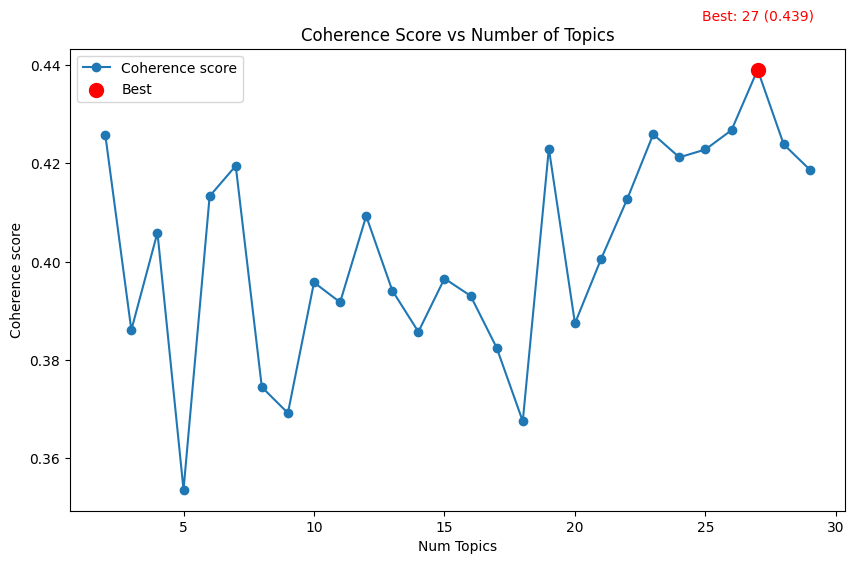

In [ ]:
# # 최고 coherence 값과 해당 토픽 수 찾기
# best_idx = np.argmax(coherence_values)
# best_num_topics = x[best_idx]
# best_coherence = coherence_values[best_idx]

# plt.figure(figsize=(10, 6))
# plt.plot(x, coherence_values, marker="o", label="Coherence score")
# plt.xlabel("Num Topics")
# plt.ylabel("Coherence score")
# plt.title("Coherence Score vs Number of Topics")

# # 최고 coherence 점 표시
# plt.scatter(best_num_topics, best_coherence, color="red", s=100, zorder=5, label="Best")
# plt.text(best_num_topics, best_coherence + 0.01,
#          f"Best: {best_num_topics} ({best_coherence:.3f})",
#          ha="center", color="red")

# plt.legend()
# plt.show()


# LDA

In [11]:
dictionary = corpora.Dictionary(tokenized_docs) 
corpus = [dictionary.doc2bow(text) for text in tokenized_docs]

# num_topics를 제외한 나머지 파라미터를 기본값으로 설정
lda_model = models.LdaModel(corpus=corpus,
                            id2word=dictionary,
                            num_topics=27, #27
                            random_state=RANDOM_STATE,
                            # update_every=1,
                            passes=10,
                            # per_word_topics=True
                            )

topics = lda_model.print_topics(num_words=50)
for idx, topic in topics:
    print(f"Topic {idx}: {topic}")

Topic 5: 0.030*"가입자" + 0.019*"체험" + 0.016*"사용자" + 0.014*"누적" + 0.014*"키즈" + 0.012*"확대" + 0.012*"공간" + 0.012*"코딩" + 0.011*"출시" + 0.011*"대상" + 0.010*"캠프" + 0.010*"기준" + 0.010*"돌파" + 0.009*"강화" + 0.009*"사업" + 0.009*"적용" + 0.009*"가상" + 0.008*"운영" + 0.008*"캐릭터" + 0.008*"대화" + 0.008*"어린이" + 0.007*"진로" + 0.007*"소통" + 0.006*"자연" + 0.006*"대표적" + 0.006*"계획" + 0.006*"이용자" + 0.006*"국가" + 0.006*"어린이들" + 0.006*"시작" + 0.006*"달성" + 0.006*"신규" + 0.006*"성장" + 0.006*"진행" + 0.005*"진학" + 0.005*"기회" + 0.005*"창출" + 0.005*"자체" + 0.005*"마이룸" + 0.005*"자사" + 0.005*"증가" + 0.005*"아이들" + 0.005*"버스" + 0.004*"역량" + 0.004*"개선" + 0.004*"구축" + 0.004*"외국어" + 0.004*"컴퓨터" + 0.004*"경험" + 0.004*"관내"
Topic 18: 0.034*"대화" + 0.017*"체험" + 0.014*"가능" + 0.013*"적용" + 0.013*"문장" + 0.012*"캐릭터" + 0.012*"직업" + 0.012*"아이들" + 0.011*"출시" + 0.011*"메타버스" + 0.011*"자유" + 0.011*"원어민" + 0.011*"영상" + 0.010*"제작" + 0.010*"이미지" + 0.010*"단어" + 0.010*"음성" + 0.009*"사용자" + 0.009*"경험" + 0.008*"친구" + 0.008*"학습자" + 0.008*"자연" + 0.008*"제품" + 0.007*"인식" + 0

# Numerical Value

In [12]:
# 각 단어의 id에 대한 토픽 분포 행렬 가져오기 (단어 수 x 토픽 수)
topic_word_matrix = lda_model.get_topics()  # shape: (num_topics, vocab_size)
word_topic_matrix = topic_word_matrix.T

# 단어 목록
words = [dictionary[id] for id in range(len(dictionary))]

df_word_topic = pd.DataFrame(word_topic_matrix, index=words, columns=[f'LDA_Topic_{i}' for i in range(lda_model.num_topics)])

# # 값 필터링 (선택사항)
# df_word_topic = df_word_topic[df_word_topic.max(axis=1) > 0.01]

# 출력
df_word_topic

,LDA_Topic_0,LDA_Topic_1,LDA_Topic_2,LDA_Topic_3,LDA_Topic_4,LDA_Topic_5,LDA_Topic_6,LDA_Topic_7,LDA_Topic_8,LDA_Topic_9,...,LDA_Topic_17,LDA_Topic_18,LDA_Topic_19,LDA_Topic_20,LDA_Topic_21,LDA_Topic_22,LDA_Topic_23,LDA_Topic_24,LDA_Topic_25,LDA_Topic_26
개개인,0.000006,0.000004,0.000010,0.000066,0.000022,0.000110,0.000007,0.000005,0.001123,0.000149,...,0.000213,0.000007,0.000013,0.000574,0.000175,0.000010,0.000026,0.000526,0.000070,0.000039
개정,0.000005,0.000003,0.000010,0.000009,0.000033,0.001174,0.000008,0.000005,0.001112,0.000307,...,0.000007,0.000007,0.000014,0.000997,0.000288,0.000583,0.000018,0.000458,0.000013,0.000038
검토,0.000921,0.000233,0.000014,0.000109,0.001256,0.000888,0.000328,0.001066,0.003352,0.000312,...,0.000395,0.000026,0.000049,0.000373,0.000667,0.000012,0.000019,0.000465,0.000628,0.000045
경험,0.000937,0.001249,0.003654,0.002961,0.002959,0.004043,0.002193,0.002497,0.000253,0.001764,...,0.001901,0.009241,0.005576,0.002300,0.001062,0.003913,0.004051,0.004451,0.003614,0.000095
계획,0.001014,0.000992,0.012323,0.006993,0.002540,0.006171,0.000390,0.006434,0.002632,0.003090,...,0.001649,0.001929,0.013027,0.003542,0.007001,0.003849,0.005627,0.001727,0.012552,0.000117
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
문자화,0.000004,0.000003,0.000007,0.000006,0.000018,0.000011,0.000006,0.000005,0.000006,0.000006,...,0.000004,0.000007,0.000011,0.000003,0.000004,0.000012,0.000010,0.000005,0.000002,0.000038
발화자,0.000004,0.000003,0.000009,0.000006,0.000019,0.000011,0.000006,0.000005,0.000006,0.000006,...,0.000004,0.000164,0.000011,0.000003,0.000004,0.000014,0.000010,0.000005,0.000002,0.000038
스트리트,0.000004,0.000003,0.000008,0.000006,0.000018,0.000010,0.000006,0.000005,0.000006,0.000006,...,0.000004,0.000007,0.000011,0.000003,0.000004,0.000014,0.000010,0.000005,0.000002,0.000038
버즈,0.000012,0.000003,0.000018,0.000193,0.000026,0.000010,0.000006,0.000005,0.000007,0.000006,...,0.000005,0.004221,0.000011,0.000004,0.000004,0.000009,0.001613,0.000007,0.000002,0.000039


In [ ]:
# df_word_topic.to_csv('/LDA_word_topic_prob.csv', index=True)

# Assess

### Modularity

In [13]:
top_k = 100  # 토픽당 상위 단어 수
topic_word_lists = []

for idx in range(lda_model.num_topics):
    topic_terms = lda_model.get_topic_terms(idx, topn=top_k)
    words = [dictionary[id] for id, _ in topic_terms]
    topic_word_lists.append(words)


In [14]:
G_topk = nx.Graph()

# 토픽별 단어쌍에 엣지를 추가
for word_list in topic_word_lists:
    for w1, w2 in combinations(sorted(word_list), 2):
        if G_topk.has_edge(w1, w2):
            G_topk[w1][w2]['weight'] += 1
        else:
            G_topk.add_edge(w1, w2, weight=1)


In [15]:
def summarize_graph(G, weight_attr="weight"):
    n = G.number_of_nodes()
    m = G.number_of_edges()

    max_edges = n * (n - 1) / 2 if not G.is_directed() else n * (n - 1)

    density = nx.density(G)
    sparsity = 1.0 - density

    print(f"노드 수: {n}")
    print(f"엣지 수: {m}")
    print(f"최대 엣지 수: {int(max_edges)}")
    print(f"밀도(density): {density:.6f}")
    print(f"희소성(sparsity): {sparsity:.6f}")

    # --- 노드별 연결 개수 (degree) ---
    degrees = dict(G.degree())
    min_node = min(degrees, key=degrees.get)
    max_node = max(degrees, key=degrees.get)

    print(f"최소 degree: {degrees[min_node]} (노드: {min_node})")
    print(f"최대 degree: {degrees[max_node]} (노드: {max_node})")
    print(f"평균 degree: {np.mean(list(degrees.values())):.2f}")

    # --- 가중치 통계 ---
    weights = np.array(
        [d.get(weight_attr, np.nan) for _, _, d in G.edges(data=True)],
        dtype=float
    )
    weights = weights[~np.isnan(weights)]

    if weights.size == 0:
        print(f"'{weight_attr}' 속성이 있는 엣지가 없습니다.")
        return

    print(f"엣지 개수(가중치 있음): {weights.size}")
    print(f"최소 weight: {weights.min():.6f}")
    print(f"최대 weight: {weights.max():.6f}")
    print(f"평균 weight: {weights.mean():.6f}")
    print(f"중앙값 weight: {np.median(weights):.6f}")
    print(f"표준편차: {weights.std(ddof=0):.6f}")



summarize_graph(G_topk, weight_attr="weight")

노드 수: 990
엣지 수: 95670
최대 엣지 수: 489555
밀도(density): 0.195422
희소성(sparsity): 0.804578
최소 degree: 99 (노드: 감지)
최대 degree: 826 (노드: 적용)
평균 degree: 193.27
엣지 개수(가중치 있음): 95670
최소 weight: 1.000000
최대 weight: 16.000000
평균 weight: 1.396990
중앙값 weight: 1.000000
표준편차: 1.068444


In [18]:
partition = community_louvain.best_partition(G_topk, weight='weight', random_state=RANDOM_STATE)
modularity_score = community_louvain.modularity(partition, G_topk, weight='weight')

print(f"Modularity (Top-{top_k} graph): {modularity_score:.4f}")


Modularity (Top-100 graph): 0.1910


In [ ]:
import json

# 저장할 데이터 구성
modularity_data = {"modularity": modularity_score}

# 파일로 저장
output_path = f"/LDA_modularity.json"
with open(output_path, "w") as f:
    json.dump(modularity_data, f, indent=4)

print(f"Modularity score saved to {output_path}")


### Coherence

In [ ]:
output_path = "/LDA_coherence.json"
metrics = ['c_v', 'u_mass', 'c_uci', 'c_npmi']

dictionary = corpora.Dictionary(tokenized_docs)
corpus = [dictionary.doc2bow(text) for text in tokenized_docs]

coherence_scores = {}
metrics = ['c_v', 'u_mass', 'c_uci', 'c_npmi']
for metric in metrics:
    cm = CoherenceModel(
        model=lda_model,
        texts=tokenized_docs,
        corpus=corpus if metric in ['u_mass'] else None,
        dictionary=dictionary,
        coherence=metric
    )
    coherence_scores[metric] = cm.get_coherence().astype('float64')

try:
    w2v_model = Word2Vec(
        tokenized_docs, 
        vector_size=100, 
        window=5, 
        min_count=2, 
        workers=1, 
        epochs=10, 
        seed=RANDOM_STATE)

    cm_w2v = CoherenceModel(
        model=lda_model,
        texts=tokenized_docs,
        dictionary=dictionary,
        coherence='c_w2v',
        keyed_vectors=w2v_model.wv
    )
    coherence_scores['c_w2v'] = cm_w2v.get_coherence().astype('float64')

except Exception as e:
    print("Word2Vec coherence 계산 실패:", e)
    coherence_scores['c_w2v'] = None
with open(output_path, "w") as f:
    json.dump(coherence_scores, f, indent=4)
print(f"LDA coherence scores saved to {output_path}")

print(coherence_scores)


LDA coherence scores saved to /Users/kookbab/Desktop/코드_최종_정리/02.Topic_Models/LDA_coherence.json
{'c_v': 0.43908018125277165, 'u_mass': -1.5880342664254556, 'c_uci': -0.7236473971560676, 'c_npmi': 0.011932256002458315, 'c_w2v': 0.5846137404441833}
